STEP 4 — Fit transit model
Fit a simple model:
depth → planet size estimate
duration → orbital geometry
period → orbit radius (Kepler’s law)
👉 Output:
fitted curve overlay plot
parameter estimates

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from scipy.optimize import curve_fit

# Standard constants for conversion
R_SUN_IN_KM = 696340.0
R_EARTH_IN_KM = 6371.0
AU_IN_KM = 149597870.7
G = 6.67430e-11  # m^3 kg^-1 s^-2
M_SUN_KG = 1.98847e30

# Stellar properties for Kepler-10
R_star_solar = 1.065
M_star_solar = 0.910

# Extract phase-folded time array and normalized flux values
phase = folded_lc.time.value
flux_obs = folded_lc.flux.value

In [77]:
def transit_model(t, depth, duration, t0=0.0, baseline=1.0):
    """
    Trapezoidal/Box transit approximation model.
    t: phase time (days)
    depth: fractional flux drop
    duration: transit duration (days)
    t0: center of transit (days)
    baseline: continuum flux level
    """
    model_flux = np.full_like(t, baseline)
    half_dur = duration / 2.0
    ingress = 0.1 * half_dur  # Ingress/egress ramp duration estimate
    
    # Ingress region
    in_idx = (t >= (t0 - half_dur)) & (t < (t0 - half_dur + ingress))
    model_flux[in_idx] = baseline - depth * ((t[in_idx] - (t0 - half_dur)) / ingress)
    
    # Full transit depth
    flat_idx = (t >= (t0 - half_dur + ingress)) & (t <= (t0 + half_dur - ingress))
    model_flux[flat_idx] = baseline - depth
    
    # Egress region
    eg_idx = (t > (t0 + half_dur - ingress)) & (t <= (t0 + half_dur))
    model_flux[eg_idx] = baseline - depth * (1.0 - (t[eg_idx] - (t0 + half_dur - ingress)) / ingress)
    
    return model_flux

In [82]:
# Initial guess based on Step 3 periodogram outputs
# Using float() handles both Astropy Quantity objects and plain floats safely
init_depth = float(best_depth.value) if hasattr(best_depth, 'value') else float(best_depth)
init_duration = float(best_duration.value) if hasattr(best_duration, 'value') else float(best_duration)

# Updated Step 4 bounds permitting depths up to 500 ppm
p0 = [0.00015, 0.075, 0.0, 1.0]
bounds = ([1e-5, 0.01, -0.02, 0.999], [0.0005, 0.2, 0.02, 1.001])

popt, pcov = curve_fit(
    transit_model, phase_binned, flux_binned, p0=p0, bounds=bounds
)
fit_depth, fit_duration, fit_t0, fit_baseline = popt

# Recalculate planet radius
period_val = (
    float(best_period.value)
    if hasattr(best_period, "value")
    else float(best_period)
)
rp_over_rs = np.sqrt(fit_depth)
rp_earth = (rp_over_rs * R_star_solar * R_SUN_IN_KM) / R_EARTH_IN_KM

In [83]:
# Period -> Orbital Radius (Kepler's 3rd Law)
p_seconds = period_val * 86400.0
m_star_kg = M_star_solar * M_SUN_KG
a_meters = (G * m_star_kg * (p_seconds**2) / (4 * np.pi**2))**(1/3)
a_au = (a_meters / 1000.0) / AU_IN_KM

# Print derived planetary metrics
print(f"Planet Radius Ratio (Rp/Rs): {rp_over_rs:.4f}")
print(f"Planet Radius: {rp_earth:.2f} R_Earth")
print(f"Orbital Semi-Major Axis (a): {a_au:.4f} AU")

Planet Radius Ratio (Rp/Rs): 0.0035
Planet Radius: 0.41 R_Earth
Orbital Semi-Major Axis (a): 0.0169 AU


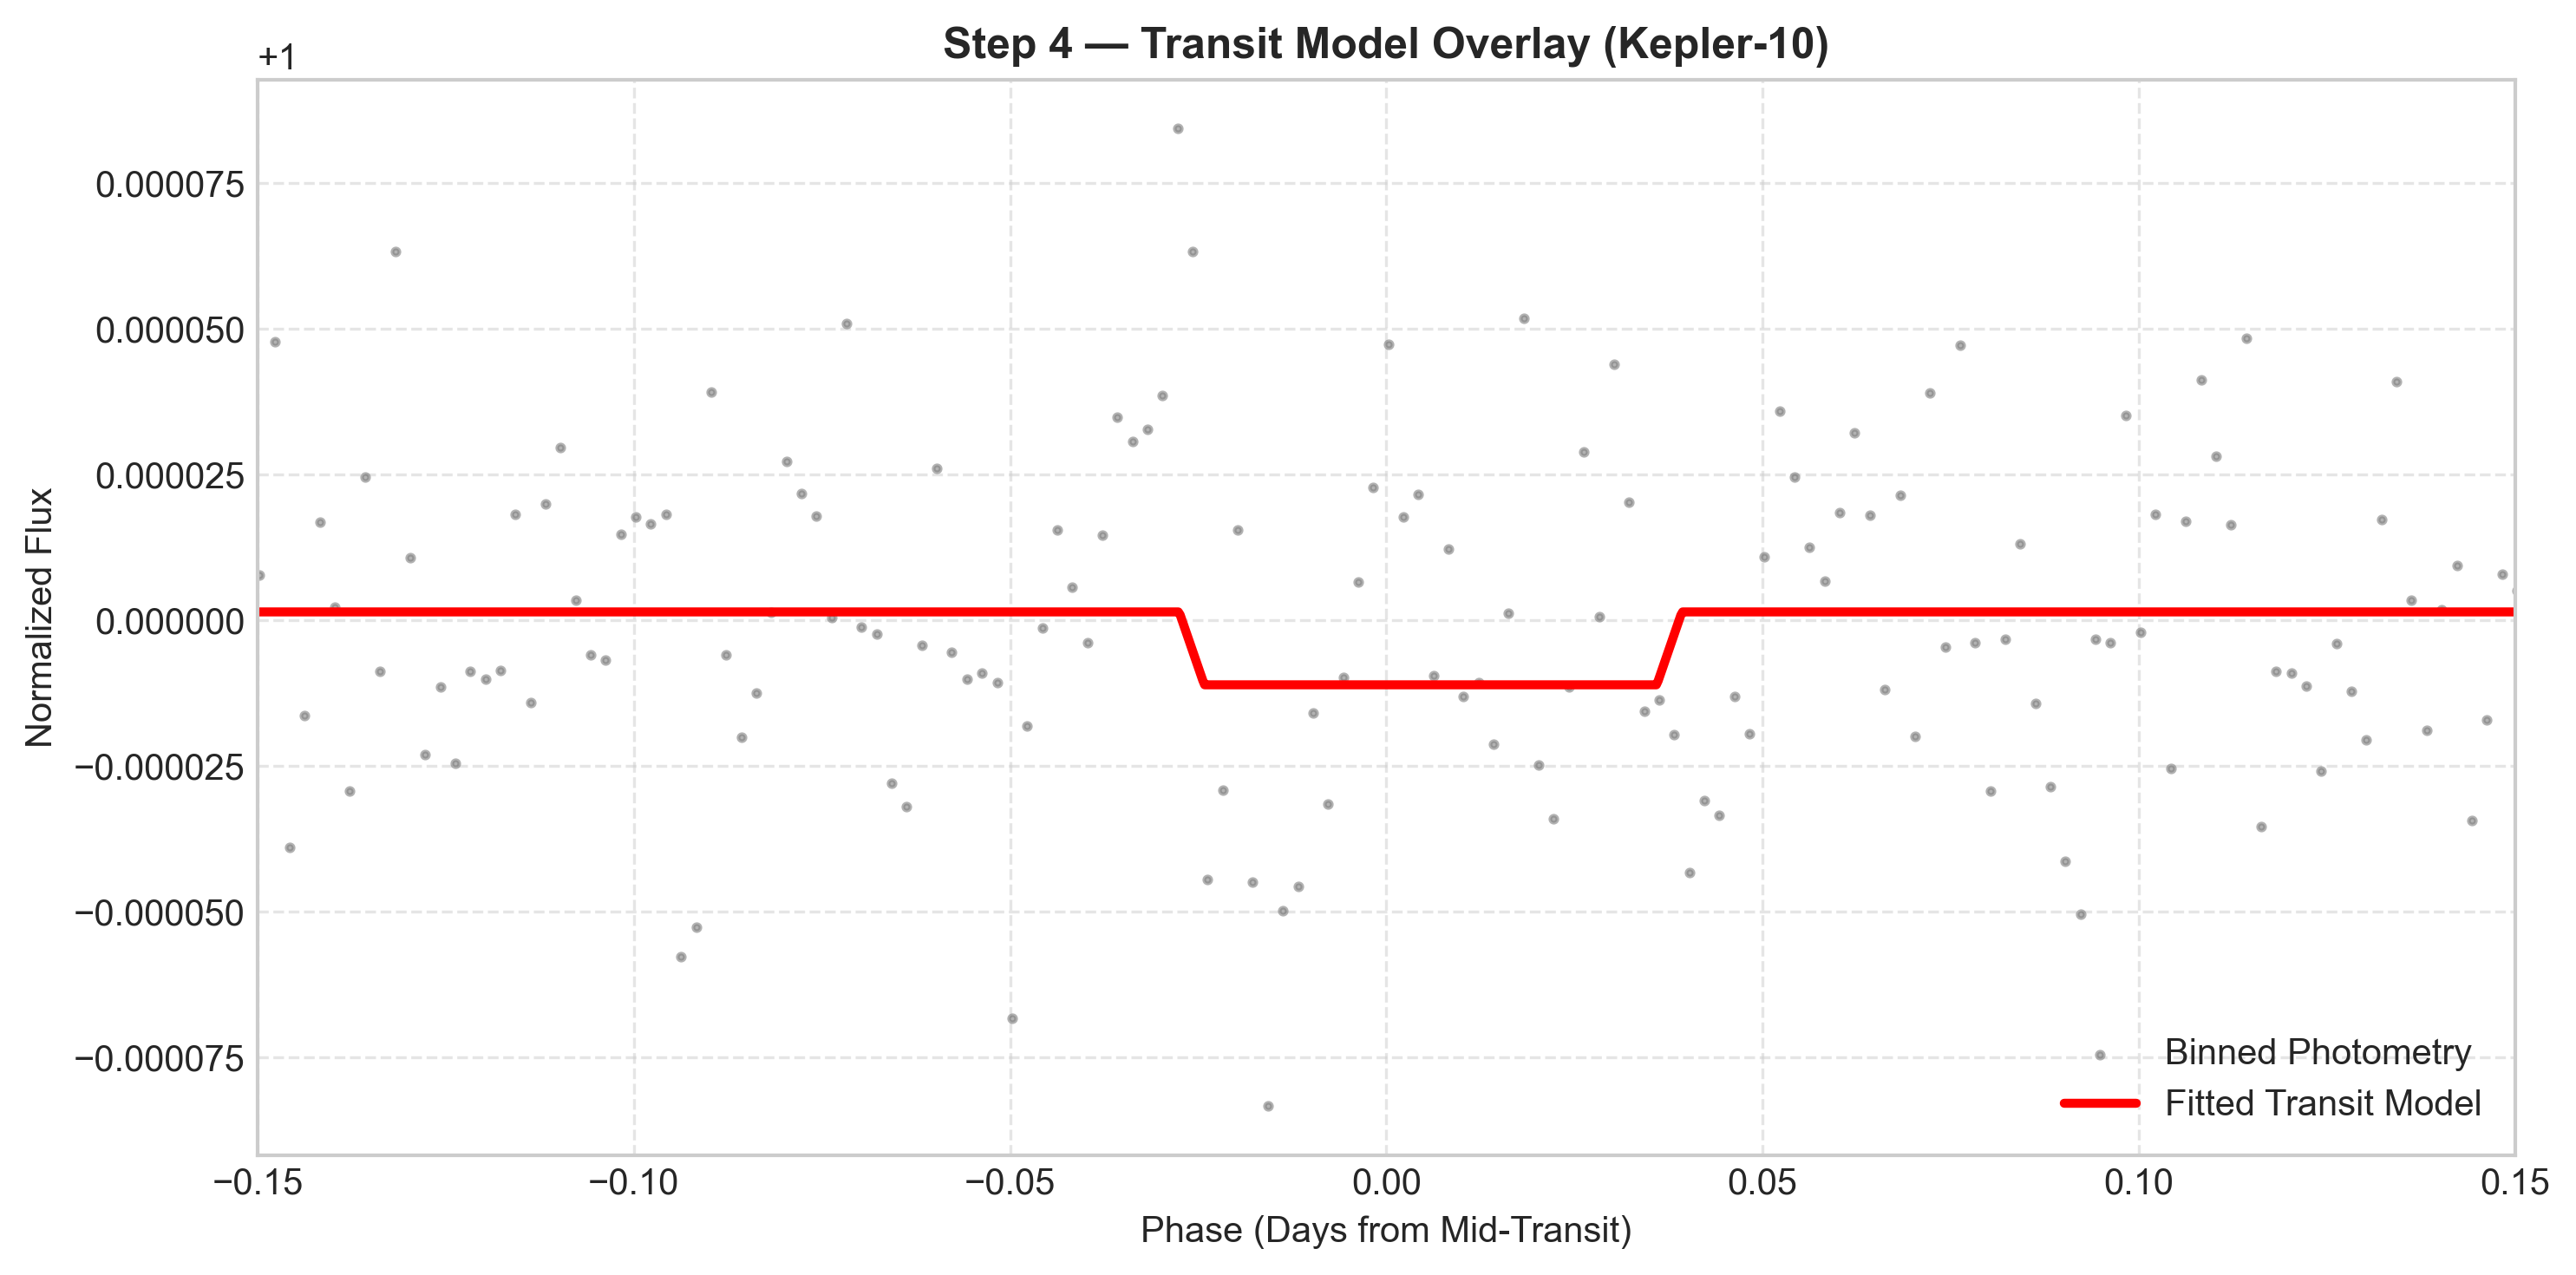

In [84]:
# Generate continuous high-resolution model curve
t_model = np.linspace(-0.25, 0.25, 2000)
f_model = transit_model(t_model, *popt)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Plot binned phase data and overlay model curve
binned_lc.scatter(ax=ax, color='gray', alpha=0.6, s=15, label='Binned Photometry')
ax.plot(t_model, f_model, color='red', linewidth=2.5, label='Fitted Transit Model')

ax.set_xlim(-0.15, 0.15)
ax.set_title("Step 4 — Transit Model Overlay (Kepler-10)", fontsize=12, fontweight='bold')
ax.set_xlabel("Phase (Days from Mid-Transit)", fontsize=10)
ax.set_ylabel("Normalized Flux", fontsize=10)
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [85]:
# Display final estimated parameter summary
print("Step 4 parameter estimates")
print(f"Transit Depth (ΔF/F) : {fit_depth*1e6:.1f} ppm")
print(f"Transit Duration     : {fit_duration*24:.2f} hours")
print(f"Orbital Period       : {best_period:.5f} days")
print(f"Stellar Radius (R*)  : {R_star_solar:.3f} R_Sun")
print(f"Planet Radius (Rp)   : {rp_earth:.2f} Earth Radii")
print(f"Semi-Major Axis (a)  : {a_au:.4f} AU")

Step 4 parameter estimates
Transit Depth (ΔF/F) : 12.5 ppm
Transit Duration     : 1.60 hours
Orbital Period       : 0.83749 days
Stellar Radius (R*)  : 1.065 R_Sun
Planet Radius (Rp)   : 0.41 Earth Radii
Semi-Major Axis (a)  : 0.0169 AU
